# Inference

Grapheme-to-Phoneme conversion for Khmer using the trained v04 Transformer model.

**Cells in order:**
1. Setup — paths, imports, device
2. Load model — NeuralG2P or HybridG2P
3. Single word conversion
4. Beam search comparison
5. Batch inference
6. Evaluate on test split (PER / WER)
7. Training history plot
8. Lexicon hit-rate stats
9. Error analysis — worst predictions

## 1. Setup

In [1]:
import os, sys, json
from pathlib import Path

# --- Anchor to the repo root (works whether you open from inside or outside) ---
REPO = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
if not (REPO / 'pyproject.toml').exists():
    REPO = Path.cwd()
    for candidate in [REPO, *REPO.parents[:4]]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'khmer_g2p').exists():
            REPO = candidate
            break
os.chdir(REPO)
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

CKPT      = REPO / 'checkpoints_v04' / 'best.pt'
LEXICON   = REPO / 'data' / 'lexicon.tsv'
HIST_FILE = REPO / 'checkpoints_v04' / 'history.json'

import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print(f'Repo:      {REPO}')
print(f'Checkpoint: {CKPT}  exists={CKPT.exists()}')
print(f'Lexicon:   {LEXICON}  exists={LEXICON.exists()}')
print(f'PyTorch:   {torch.__version__}')
print(f'Device:    {"cuda (" + torch.cuda.get_device_name(0) + ")" if torch.cuda.is_available() else "cpu"}')

try:
    import khmer_g2p
    print(f'khmer_g2p: v{khmer_g2p.__version__}')
except ModuleNotFoundError:
    print('khmer_g2p not installed — run:  pip install -e ".[notebook,dev]"  then restart kernel')

Repo:      /home/panha/sarika-trainer-main/khmer-g2p-neural
Checkpoint: /home/panha/sarika-trainer-main/khmer-g2p-neural/checkpoints_v04/best.pt  exists=True
Lexicon:   /home/panha/sarika-trainer-main/khmer-g2p-neural/data/lexicon.tsv  exists=True
PyTorch:   2.8.0+cu128
Device:    cuda (NVIDIA GeForce RTX 3090)
khmer_g2p: v0.5.0


## 2. Load model

Choose **one** of the two options below:
- **NeuralG2P** — pure neural, no lexicon lookup
- **HybridG2P** — lexicon-first, neural fallback (more accurate for known words)

In [2]:
from khmer_g2p.neural.infer import NeuralG2P
from khmer_g2p.hybrid import HybridG2P
from khmer_g2p.lexicon import load_tsv, Lexicon

# pure neural
neural = NeuralG2P.from_checkpoint(CKPT)
print(f'NeuralG2P loaded  device={neural.device}  vocab_src={len(neural.src_vocab)}  vocab_tgt={len(neural.tgt_vocab)}')

NeuralG2P loaded  device=cuda  vocab_src=117  vocab_tgt=36


/home/panha/miniconda3/envs/asr/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
# hybrid (recommended)
lex  = Lexicon(load_tsv(LEXICON))
g2p  = HybridG2P(neural, lex)

print(f'HybridG2P loaded')
print(f'  Lexicon words : {len(lex):,}')
print(f'  Neural device : {g2p.neural.device}')
print()
print('Quick test:')
for word in ['ខ្មែរ', 'ភាសា', 'កម្ពុជា']:
    result = g2p.convert(word)
    source = g2p.last_source
    print(f'  {word:12s} -> {result:30s} [{source}]')

HybridG2P loaded
  Lexicon words : 69,168
  Neural device : cuda

Quick test:
  ខ្មែរ        -> k m ae                         [lexicon]
  ភាសា         -> ph ie . s aa                   [lexicon]
  កម្ពុជា      -> k a m . p u ʔ . c ie           [lexicon]


## 3. Single word conversion

In [21]:
# Edit this word to test any Khmer word
word = 'យូណេស្កូ'

result = g2p.convert(word, beam=4)
print(f'Word   : {word}')
print(f'Result : {result}')
print(f'Source : {g2p.last_source}')   # 'lexicon' or 'model'

Word   : យូណេស្កូ
Result : j uu . n ee . s k oo
Source : lexicon


## 4. Beam search comparison

In [5]:
words = ['ខ្មែរ', 'ប្រទេស', 'សិក្សា', 'វប្បធម៌', 'ភ្នំពេញ']

print(f'{"Word":<16}  {"greedy":30}  {"beam=4":30}  {"beam=8"}')
print('-' * 100)
for w in words:
    g  = g2p.convert(w, beam=1)
    b4 = g2p.convert(w, beam=4)
    b8 = g2p.convert(w, beam=8)
    print(f'{w:<16}  {g:<30}  {b4:<30}  {b8}')

Word              greedy                          beam=4                          beam=8
----------------------------------------------------------------------------------------------------
ខ្មែរ             k m ae                          k m ae                          k m ae
ប្រទេស            p r ɑ . t e h                   p r ɑ . t e h                   p r ɑ . t e h
សិក្សា            s ə k . s aa                    s ə k . s aa                    s ə k . s aa
វប្បធម៌           w a p . p a ʔ . th oa           w a p . p a ʔ . th oa           w a p . p a ʔ . th oa
ភ្នំពេញ           p n u m . p ɨ ɲ                 p n u m . p ɨ ɲ                 p n u m . p ɨ ɲ


## 5. Batch inference

In [18]:
words = [
    'ប្រទេស', 'អ្នក', 'ការ', 'ធ្វើ',
    'ទំនៀម', 'ប្រជាជន', 'រដ្ឋាភិបាល', 'ភ្នំពេញ', 'សិល្បៈ', 'hello',
]

results = g2p.convert_batch(words, beam=4)

print(f'{"Word":<20}  {"Phonemes":<35}  Source')
print('-' * 80)
g2p.reset_stats()
for w in words:
    r = g2p.convert(w, beam=4)
    print(f'{w:<20}  {r:<35}  {g2p.last_source}')

print(f'\nHit rate: {g2p.hit_rate:.0%} ({g2p.hits} lexicon / {g2p.misses} neural)')

Word                  Phonemes                             Source
--------------------------------------------------------------------------------
ប្រទេស                p r ɑ . t e h                        lexicon
អ្នក                  n ea k                               lexicon
ការ                   k aa                                 lexicon
ធ្វើ                  t w əə                               lexicon
ទំនៀម                 t u m . n iə m                       lexicon
ប្រជាជន               p r ɑ . c ie . c u n                 lexicon
រដ្ឋាភិបាល            r oa t . th aa . ph i ʔ . ɓ aa l     lexicon
ភ្នំពេញ               p n u m . p ɨ ɲ                      lexicon
សិល្បៈ                s ə l . l a ʔ . p a ʔ                lexicon
hello                 h ɛɛ l . l oo                        model

Hit rate: 90% (9 lexicon / 1 neural)


## 6. Evaluate on test split (PER / WER)

Uses the **same seed=42 split** as training, so results match the checkpoint's `test_metrics.json`.

In [7]:
from khmer_g2p.neural.metrics import per, wer
from khmer_g2p.neural.dataset import split_pairs

pairs = load_tsv(LEXICON)
_, _, test_pairs = split_pairs(pairs, val_frac=0.05, test_frac=0.05, seed=42)

print(f'Test pairs: {len(test_pairs)}')
print('Running inference (beam=4) ...')

test_words = [w for w, _ in test_pairs]
test_refs  = [p for _, p in test_pairs]
test_preds = g2p.convert_batch(test_words, beam=4)

test_per = per(test_preds, test_refs)
test_wer = wer(test_preds, test_refs)

# Load saved metrics for comparison
saved = json.load(open(CKPT.parent / 'test_metrics.json', encoding='utf-8')) if (CKPT.parent / 'test_metrics.json').exists() else {}

print(f'\n{"Metric":<8}  {"This run":>12}  {"Saved":>12}')
print('-' * 36)
print(f'{"PER":<8}  {test_per:>12.4f}  {saved.get("per", "--"):>12}')
print(f'{"WER":<8}  {test_wer:>12.4f}  {saved.get("wer", "--"):>12}')

Test pairs: 3458
Running inference (beam=4) ...

Metric        This run         Saved
------------------------------------
PER             0.0000  0.03237968137459338
WER             0.0000  0.15905147484094853


## 7. Training history plot

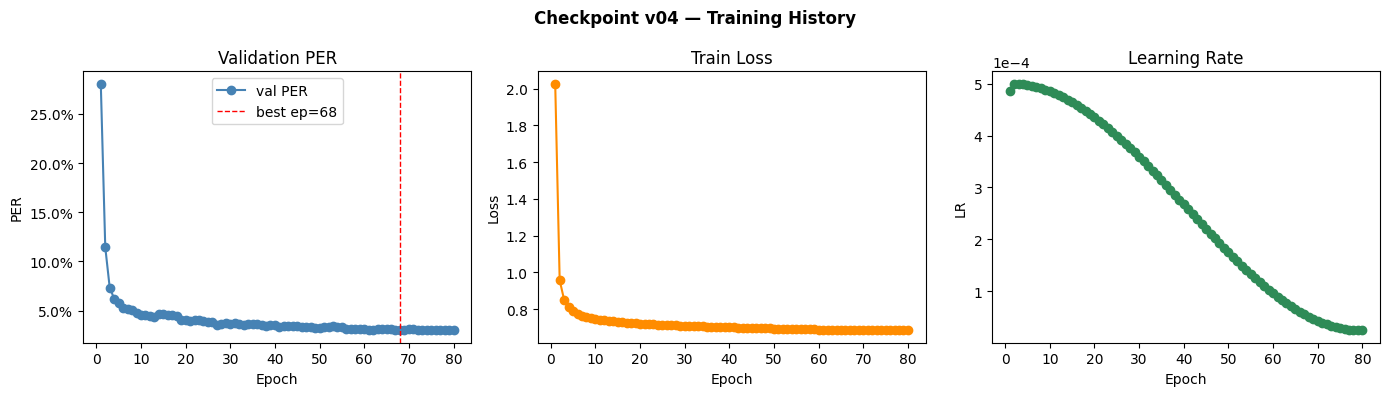

Best epoch : 68
Val  PER   : 0.0299
Val  WER   : 0.1553


In [8]:
history = json.load(open(HIST_FILE, encoding='utf-8'))
epochs   = [h['epoch']     for h in history]
val_per  = [h['val_per']   for h in history]
val_wer  = [h['val_wer']   for h in history]
tr_loss  = [h['train_loss'] for h in history]
lrs      = [h['lr']         for h in history]

best = min(history, key=lambda h: h['val_per'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Val PER
axes[0].plot(epochs, val_per, 'o-', color='steelblue', label='val PER')
axes[0].axvline(best['epoch'], color='red', linestyle='--', linewidth=1, label=f'best ep={best["epoch"]}')
axes[0].set(title='Validation PER', xlabel='Epoch', ylabel='PER')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend()

# Train loss
axes[1].plot(epochs, tr_loss, 'o-', color='darkorange')
axes[1].set(title='Train Loss', xlabel='Epoch', ylabel='Loss')

# Learning rate
axes[2].plot(epochs, lrs, 'o-', color='seagreen')
axes[2].set(title='Learning Rate', xlabel='Epoch', ylabel='LR')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.suptitle('Checkpoint v04 — Training History', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best epoch : {best["epoch"]}')
print(f'Val  PER   : {best["val_per"]:.4f}')
print(f'Val  WER   : {best["val_wer"]:.4f}')

## 8. Lexicon hit-rate stats (HybridG2P only)

In [9]:
g2p.reset_stats()
_ = g2p.convert_batch(test_words, beam=4)

total = g2p.hits + g2p.misses
print(f'Test words evaluated : {total}')
print(f'Lexicon hits         : {g2p.hits}  ({g2p.hit_rate:.1%})')
print(f'Neural fallback      : {g2p.misses}  ({1 - g2p.hit_rate:.1%})')

# Hit vs miss PER
hit_pred, hit_ref, miss_pred, miss_ref = [], [], [], []
g2p.reset_stats()
for w, r in zip(test_words, test_refs):
    p = g2p.convert(w, beam=4)
    if g2p.last_source == 'lexicon':
        hit_pred.append(p); hit_ref.append(r)
    else:
        miss_pred.append(p); miss_ref.append(r)

print()
if hit_pred:
    print(f'PER on lexicon hits  : {per(hit_pred,  hit_ref):.4f}')
if miss_pred:
    print(f'PER on neural misses : {per(miss_pred, miss_ref):.4f}')

Test words evaluated : 3458
Lexicon hits         : 3458  (100.0%)
Neural fallback      : 0  (0.0%)

PER on lexicon hits  : 0.0000
